<a href="https://colab.research.google.com/github/amit-devs/Amit_ML_Practicals/blob/main/Postlab_ML_CS23091.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor  # ✅ ADD THIS


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/ML_DATASETS/Gaming and Mental Health.csv"
df = pd.read_csv(path)

print("Dataset Loaded Successfully")
print(df.head())


Dataset Loaded Successfully
  record_id  age  gender  daily_gaming_hours     game_genre    primary_game  \
0    GD0001   17    Male                11.1   Mobile Games  Clash of Clans   
1    GD0002   21    Male                 3.0           MOBA          Dota 2   
2    GD0003   23    Male                 7.6            FPS           CS:GO   
3    GD0004   20  Female                 7.2            RPG          Skyrim   
4    GD0005   18    Male                 6.8  Battle Royale    Apex Legends   

  gaming_platform  sleep_hours sleep_quality sleep_disruption_frequency  ...  \
0              PC          3.7     Very Poor                  Sometimes  ...   
1              PC          7.2          Fair                     Rarely  ...   
2  Multi-platform          4.4          Fair                      Often  ...   
3  Multi-platform          5.1          Fair                      Often  ...   
4              PC          3.4          Poor                      Never  ...   

  continued_desp

In [ ]:
# ==============================
# 4. Data Preprocessing
# ==============================

# Drop unnecessary column
df.drop(['record_id'], axis=1, inplace=True)

# Remove missing values
df = df.dropna()

# Convert categorical → numerical (BEST METHOD)
df = pd.get_dummies(df, drop_first=True)

print("After preprocessing shape:", df.shape)

After preprocessing shape: (428, 78)


In [ ]:
print(df.columns)

Index(['age', 'daily_gaming_hours', 'sleep_hours', 'grades_gpa',
       'work_productivity_score', 'withdrawal_symptoms',
       'loss_of_other_interests', 'continued_despite_problems', 'eye_strain',
       'back_neck_pain', 'weight_change_kg', 'exercise_hours_weekly',
       'social_isolation_score', 'face_to_face_social_hours_weekly',
       'monthly_game_spending_usd', 'years_gaming', 'gender_Male',
       'gender_Other', 'game_genre_FPS', 'game_genre_MMO', 'game_genre_MOBA',
       'game_genre_Mobile Games', 'game_genre_RPG', 'game_genre_Strategy',
       'primary_game_Apex Legends', 'primary_game_CS:GO',
       'primary_game_Call of Duty', 'primary_game_Candy Crush',
       'primary_game_Civilization VI', 'primary_game_Clash of Clans',
       'primary_game_Cyberpunk 2077', 'primary_game_Dota 2',
       'primary_game_Elden Ring', 'primary_game_Elder Scrolls Online',
       'primary_game_Final Fantasy XIV', 'primary_game_Fortnite',
       'primary_game_Genshin Impact', 'primary_game

In [ ]:
# ==============================
# 5. Define Features & Target
# ==============================
X = df[['age',
        'daily_gaming_hours',
        'sleep_hours',
        'exercise_hours_weekly',
        'social_isolation_score',
        'monthly_game_spending_usd',
        'years_gaming']]

y = df['grades_gpa']

In [ ]:
# ==============================
# 6. Train-Test Split
# ==============================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
# ==============================
# 7. Feature Scaling
# ==============================
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
# ==============================
# 8. Train Model (BEST MODEL)
# ==============================
model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    random_state=42
)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# ==============================
# 9. Prediction
# ==============================
y_pred = model.predict(X_test)


In [ ]:
# ==============================
# 10. Evaluation
# ==============================
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("MSE:", mse)
print("RMSE:", rmse)



===== MODEL PERFORMANCE =====
MSE: 0.7333914128779065
RMSE: 0.8563827490543621


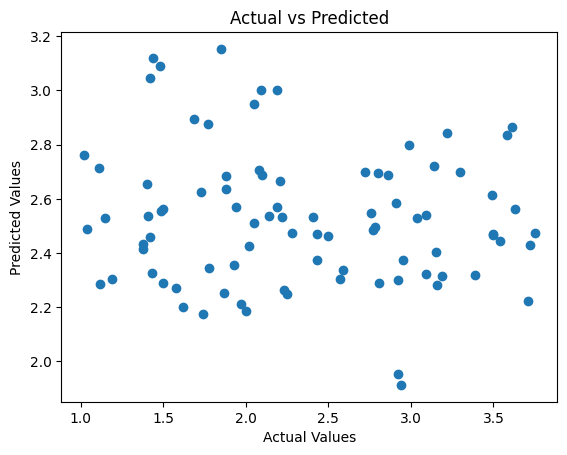

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

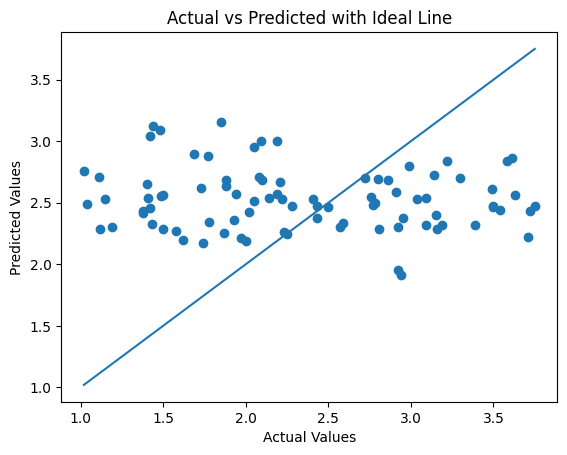

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted with Ideal Line")

plt.show()